# 08 — ML Models

**Étape 10 — ML (Random Forest + Gradient Boosting/XGBoost)**

Modèles non linéaires capables de capturer les interactions entre
fondamentaux (section 10, niveau 4). Modèle ML principal recommandé : XGBoost.


## Setup

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import data, features, models, backtest, metrics, plots

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (14, 4)


## Random Forest (`src/models.py::fit_random_forest`) — baseline ML

In [2]:
from pathlib import Path

DATA_PATH = Path("../data/processed/dataset_features.csv")

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df = df.set_index("datetime").sort_index()

SAFE_MODEL_FEATURES = [
    "price_da_lag_1d",
    "price_da_lag_2d",
    "price_da_lag_7d",
    "price_da_rollmean_1d",
    "price_da_rollstd_1d",
    "price_da_rollmean_7d",
    "price_da_rollstd_7d",
    "hour",
    "weekday",
    "is_weekend",
    "month",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",
    "is_holiday",
]

TARGET = "price_da"

TRAIN_END = pd.Timestamp(
    "2024-01-01 00:00",
    tz="Europe/Paris",
)

VALIDATION_END = pd.Timestamp(
    "2025-01-01 00:00",
    tz="Europe/Paris",
)

train_raw, validation_raw, test_raw = backtest.chronological_split(
    df,
    train_end=TRAIN_END,
    val_end=VALIDATION_END,
)

train = train_raw.dropna(
    subset=SAFE_MODEL_FEATURES + [TARGET]
).copy()

validation = validation_raw.dropna(
    subset=SAFE_MODEL_FEATURES + [TARGET]
).copy()

test = test_raw.dropna(
    subset=SAFE_MODEL_FEATURES + [TARGET]
).copy()

X_train = train[SAFE_MODEL_FEATURES]
y_train = train[TARGET]

X_validation = validation[SAFE_MODEL_FEATURES]
y_validation = validation[TARGET]

X_test = test[SAFE_MODEL_FEATURES]
y_test = test[TARGET]

assert X_train.shape == (17344, 18)
assert X_validation.shape == (8780, 18)
assert X_test.shape == (6548, 18)

# Baseline Random Forest raisonnablement régularisée
random_forest_model = models.fit_random_forest(
    X_train,
    y_train,
    n_estimators=400,
    max_depth=18,
    min_samples_leaf=2,
    max_features=0.8,
    n_jobs=-1,
    random_state=42,
)

rf_validation_pred = pd.Series(
    random_forest_model.predict(X_validation),
    index=X_validation.index,
    name="Random Forest",
)

rf_validation_metrics = metrics.summary_metrics(
    y_validation,
    rf_validation_pred,
)

print("Dimensions train :", X_train.shape)
print("Dimensions validation :", X_validation.shape)
print("Dimensions test :", X_test.shape)
print()
print("Random Forest — validation uniquement")
display(pd.DataFrame([rf_validation_metrics]))

Dimensions train : (17344, 18)
Dimensions validation : (8780, 18)
Dimensions test : (6548, 18)

Random Forest — validation uniquement


,MAE,RMSE,sMAPE,Bias,n_obs
0,19.522286,25.035611,52.632311,-2.323464,8780


## Gradient Boosting / XGBoost (`fit_xgboost`) — modèle principal

In [3]:
xgboost_initial_model = models.fit_xgboost(
    X_train,
    y_train,
    n_estimators=800,
    max_depth=6,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

xgb_initial_validation_pred = pd.Series(
    xgboost_initial_model.predict(X_validation),
    index=X_validation.index,
    name="XGBoost initial",
)

xgb_initial_validation_metrics = metrics.summary_metrics(
    y_validation,
    xgb_initial_validation_pred,
)

print("XGBoost initial — validation uniquement")
display(pd.DataFrame([xgb_initial_validation_metrics]))

XGBoost initial — validation uniquement


,MAE,RMSE,sMAPE,Bias,n_obs
0,20.335421,26.084131,53.755263,-6.130814,8780


## Tuning des hyperparamètres sur la validation (jamais sur le test !)

In [4]:
XGB_CANDIDATES = [
    {
        "max_depth": 3,
        "learning_rate": 0.03,
        "n_estimators": 600,
        "min_child_weight": 5,
    },
    {
        "max_depth": 3,
        "learning_rate": 0.05,
        "n_estimators": 500,
        "min_child_weight": 5,
    },
    {
        "max_depth": 4,
        "learning_rate": 0.03,
        "n_estimators": 800,
        "min_child_weight": 5,
    },
    {
        "max_depth": 4,
        "learning_rate": 0.05,
        "n_estimators": 600,
        "min_child_weight": 5,
    },
    {
        "max_depth": 6,
        "learning_rate": 0.03,
        "n_estimators": 800,
        "min_child_weight": 5,
    },
    {
        "max_depth": 6,
        "learning_rate": 0.05,
        "n_estimators": 500,
        "min_child_weight": 5,
    },
]

tuning_rows = []
tuned_models = {}

for candidate_id, candidate in enumerate(XGB_CANDIDATES, start=1):
    model = models.fit_xgboost(
        X_train,
        y_train,
        **candidate,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )

    validation_prediction = model.predict(X_validation)

    validation_metrics = metrics.summary_metrics(
        y_validation,
        validation_prediction,
    )

    tuned_models[candidate_id] = model

    tuning_rows.append(
        {
            "candidate_id": candidate_id,
            **candidate,
            "validation_MAE": validation_metrics["MAE"],
            "validation_RMSE": validation_metrics["RMSE"],
            "validation_sMAPE": validation_metrics["sMAPE"],
            "validation_Bias": validation_metrics["Bias"],
        }
    )

xgb_tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values("validation_RMSE")
    .reset_index(drop=True)
)

display(
    xgb_tuning_results.style.format(
        {
            "learning_rate": "{:.3f}",
            "validation_MAE": "{:.2f}",
            "validation_RMSE": "{:.2f}",
            "validation_sMAPE": "{:.2f}",
            "validation_Bias": "{:.2f}",
        }
    )
)

best_candidate_id = int(
    xgb_tuning_results.iloc[0]["candidate_id"]
)

best_xgb_model = tuned_models[best_candidate_id]

best_xgb_validation_pred = pd.Series(
    best_xgb_model.predict(X_validation),
    index=X_validation.index,
    name="XGBoost tuned",
)

best_xgb_validation_metrics = metrics.summary_metrics(
    y_validation,
    best_xgb_validation_pred,
)

# Choix final effectué uniquement avec la RMSE de validation
ml_selection_table = pd.DataFrame(
    [
        {
            "model": "Random Forest",
            "validation_MAE": rf_validation_metrics["MAE"],
            "validation_RMSE": rf_validation_metrics["RMSE"],
        },
        {
            "model": "XGBoost tuned",
            "validation_MAE": best_xgb_validation_metrics["MAE"],
            "validation_RMSE": best_xgb_validation_metrics["RMSE"],
        },
    ]
).sort_values("validation_RMSE")

display(ml_selection_table)

locked_model_name = ml_selection_table.iloc[0]["model"]

if locked_model_name == "Random Forest":
    locked_model = random_forest_model
else:
    locked_model = best_xgb_model

print("Modèle verrouillé avant consultation du test :", locked_model_name)
print("Meilleur candidat XGBoost :", best_candidate_id)

# Le modèle est maintenant verrouillé.
# Les prédictions test peuvent être calculées.
rf_test_pred = pd.Series(
    random_forest_model.predict(X_test),
    index=X_test.index,
    name="Random Forest",
)

xgb_initial_test_pred = pd.Series(
    xgboost_initial_model.predict(X_test),
    index=X_test.index,
    name="XGBoost initial",
)

best_xgb_test_pred = pd.Series(
    best_xgb_model.predict(X_test),
    index=X_test.index,
    name="XGBoost tuned",
)

if locked_model_name == "Random Forest":
    locked_test_pred = rf_test_pred
else:
    locked_test_pred = best_xgb_test_pred

,candidate_id,max_depth,learning_rate,n_estimators,min_child_weight,validation_MAE,validation_RMSE,validation_sMAPE,validation_Bias
0,1,3,0.030,600,5,19.61,25.08,52.42,-4.98
1,5,6,0.030,800,5,20.34,26.08,53.76,-6.13
2,2,3,0.050,500,5,20.45,26.27,53.34,-7.35
3,3,4,0.030,800,5,20.53,26.53,53.99,-6.29
4,4,4,0.050,600,5,20.88,26.66,55.83,-4.85
5,6,6,0.050,500,5,20.89,26.80,55.03,-5.79


,model,validation_MAE,validation_RMSE
0,Random Forest,19.522286,25.035611
1,XGBoost tuned,19.614834,25.075680


Modèle verrouillé avant consultation du test : Random Forest
Meilleur candidat XGBoost : 1


## Feature importance (native + SHAP)

,importance_native
price_da_lag_1d,0.499113
price_da_rollmean_1d,0.146851
price_da_lag_7d,0.096658
price_da_rollmean_7d,0.035266
hour_sin,0.030159
is_weekend,0.029827
weekday,0.026077
price_da_lag_2d,0.024809
month_cos,0.021802
weekday_cos,0.019423


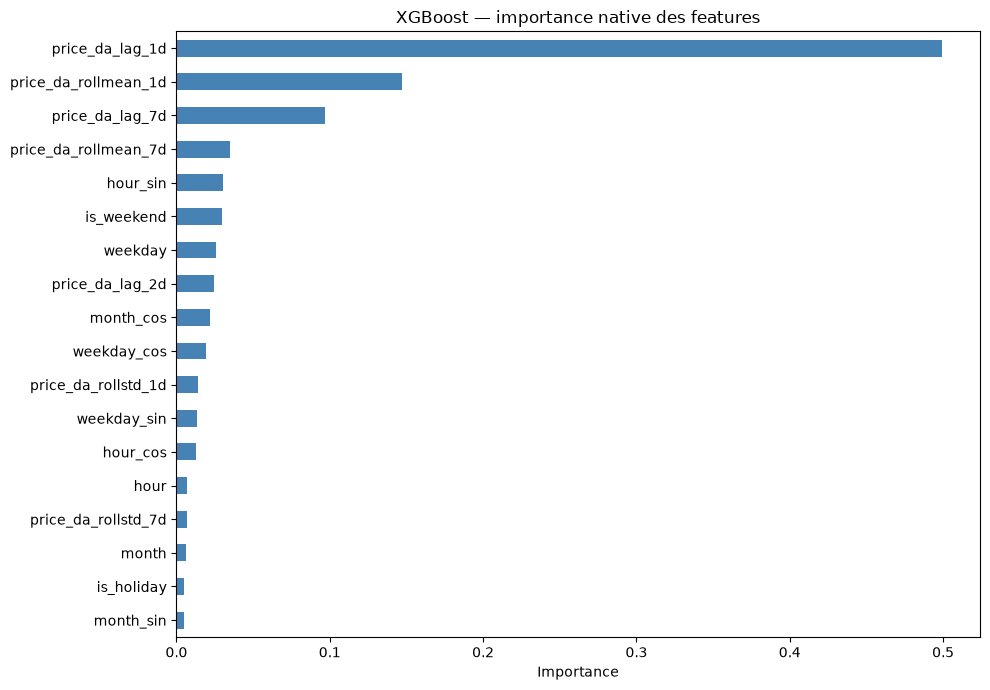

In [5]:
native_importance = (
    pd.Series(
        best_xgb_model.feature_importances_,
        index=SAFE_MODEL_FEATURES,
        name="importance_native",
    )
    .sort_values(ascending=False)
)

display(native_importance.to_frame())

fig, ax = plt.subplots(figsize=(10, 7))

native_importance.sort_values().plot(
    kind="barh",
    ax=ax,
    color="steelblue",
)

ax.set_title("XGBoost — importance native des features")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Comparaison avec les baselines et modèles statistiques

In [6]:
# Résultats test validés dans les notebooks 06 et 07.
# Toutes ces valeurs portent sur les mêmes 6 548 observations.
previous_test_benchmark = pd.DataFrame(
    [
        {
            "model": "Moyenne horaire",
            "MAE": 125.82,
            "RMSE": 134.67,
            "sMAPE": 112.85,
            "Bias": -125.55,
            "n_obs": 6548,
        },
        {
            "model": "Naive J-7",
            "MAE": 31.35,
            "RMSE": 43.31,
            "sMAPE": 78.95,
            "Bias": -1.37,
            "n_obs": 6548,
        },
        {
            "model": "OLS",
            "MAE": 23.08,
            "RMSE": 29.53,
            "sMAPE": 66.06,
            "Bias": -2.90,
            "n_obs": 6548,
        },
        {
            "model": "Ridge",
            "MAE": 23.03,
            "RMSE": 29.42,
            "sMAPE": 65.82,
            "Bias": -3.03,
            "n_obs": 6548,
        },
        {
            "model": "Lasso",
            "MAE": 22.45,
            "RMSE": 28.67,
            "sMAPE": 64.53,
            "Bias": -3.08,
            "n_obs": 6548,
        },
        {
            "model": "Naive J-1",
            "MAE": 20.40,
            "RMSE": 29.39,
            "sMAPE": 64.72,
            "Bias": -0.14,
            "n_obs": 6548,
        },
        {
            "model": "SARIMA",
            "MAE": 19.78,
            "RMSE": 26.14,
            "sMAPE": 61.00,
            "Bias": 0.50,
            "n_obs": 6548,
        },
    ]
)

ml_test_predictions = {
    "Random Forest": rf_test_pred,
    "XGBoost initial": xgb_initial_test_pred,
    "XGBoost tuned": best_xgb_test_pred,
}

ml_test_rows = []

for model_name, prediction in ml_test_predictions.items():
    result = metrics.summary_metrics(
        y_test,
        prediction,
    )

    ml_test_rows.append(
        {
            "model": model_name,
            **result,
        }
    )

ml_test_benchmark = pd.DataFrame(ml_test_rows)

final_test_benchmark = pd.concat(
    [
        previous_test_benchmark,
        ml_test_benchmark,
    ],
    ignore_index=True,
)

final_test_benchmark = (
    final_test_benchmark
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(
    final_test_benchmark.style.format(
        {
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "sMAPE": "{:.2f}",
            "Bias": "{:.2f}",
            "n_obs": "{:.0f}",
        }
    )
)

sarima_rmse = float(
    final_test_benchmark.loc[
        final_test_benchmark["model"] == "SARIMA",
        "RMSE",
    ].iloc[0]
)

locked_metrics = metrics.summary_metrics(
    y_test,
    locked_test_pred,
)

rmse_gain_vs_sarima = (
    100
    * (sarima_rmse - locked_metrics["RMSE"])
    / sarima_rmse
)

print("Modèle ML verrouillé :", locked_model_name)
print(
    "RMSE test du modèle ML :",
    round(locked_metrics["RMSE"], 2),
)

print(
    "Amélioration de RMSE face à SARIMA :",
    round(rmse_gain_vs_sarima, 2),
    "%",
)

,model,MAE,RMSE,sMAPE,Bias,n_obs
0,SARIMA,19.78,26.14,61.00,0.50,6548
1,Lasso,22.45,28.67,64.53,-3.08,6548
2,Naive J-1,20.40,29.39,64.72,-0.14,6548
3,Ridge,23.03,29.42,65.82,-3.03,6548
4,OLS,23.08,29.53,66.06,-2.90,6548
5,XGBoost tuned,23.39,30.26,61.35,-11.87,6548
6,Random Forest,22.99,30.68,59.95,-9.36,6548
7,XGBoost initial,24.04,31.62,62.47,-12.82,6548
8,Naive J-7,31.35,43.31,78.95,-1.37,6548
9,Moyenne horaire,125.82,134.67,112.85,-125.55,6548


Modèle ML verrouillé : Random Forest
RMSE test du modèle ML : 30.68
Amélioration de RMSE face à SARIMA : -17.38 %


## Sauvegarde du meilleur modèle dans `models/`

In [7]:
import json
import joblib
from datetime import datetime, timezone

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "best_ml_model.joblib"
METADATA_PATH = MODEL_DIR / "best_ml_model_metadata.json"
BENCHMARK_PATH = Path(
    "../data/processed/final_model_benchmark.csv"
)

model_artifact = {
    "model": locked_model,
    "model_name": locked_model_name,
    "feature_columns": SAFE_MODEL_FEATURES,
    "target_column": TARGET,
    "timezone": "Europe/Paris",
    "forecast_origin": "11:00 Europe/Paris D-1",
    "train_end_exclusive": str(TRAIN_END),
    "validation_end_exclusive": str(VALIDATION_END),
}

joblib.dump(model_artifact, MODEL_PATH)

metadata = {
    "model_name": locked_model_name,
    "feature_columns": SAFE_MODEL_FEATURES,
    "target_column": TARGET,
    "selection_metric": "validation_RMSE",
    "test_metrics": {
        key: float(value)
        for key, value in locked_metrics.items()
    },
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "anti_leakage": {
        "safe_features_only": True,
        "test_used_for_tuning": False,
        "realized_fundamentals_used": False,
    },
}

with open(METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(
        metadata,
        file,
        indent=2,
        ensure_ascii=False,
    )

final_test_benchmark.to_csv(
    BENCHMARK_PATH,
    index=False,
)

# Vérification immédiate du fichier sauvegardé
loaded_artifact = joblib.load(MODEL_PATH)

assert (
    loaded_artifact["feature_columns"]
    == SAFE_MODEL_FEATURES
)

loaded_predictions = loaded_artifact["model"].predict(
    X_test.head(24)
)

expected_predictions = locked_model.predict(
    X_test.head(24)
)

np.testing.assert_allclose(
    loaded_predictions,
    expected_predictions,
)

print("Modèle sauvegardé :", MODEL_PATH.resolve())
print("Métadonnées :", METADATA_PATH.resolve())
print("Benchmark :", BENCHMARK_PATH.resolve())
print("Rechargement du modèle validé.")

Modèle sauvegardé : /Users/evitafaj/Desktop/Portofolio/electricity-price-forecasting/models/best_ml_model.joblib
Métadonnées : /Users/evitafaj/Desktop/Portofolio/electricity-price-forecasting/models/best_ml_model_metadata.json
Benchmark : /Users/evitafaj/Desktop/Portofolio/electricity-price-forecasting/data/processed/final_model_benchmark.csv
Rechargement du modèle validé.
